# 1. Preparing Data for CNN Input

- Load preprocessed log-mel spectrograms and labels from `.npy` files.  
- Inspect shapes and dtypes to confirm the data matches expectations.  
- Add a channel dimension and cast spectrograms to `float32` so they are ready for Keras/TensorFlow.
- Split each spectrogram into smaller time windows so the CNN can learn local audio patterns.
- Increases dataset size, to give CNN more examples to learn from.


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

In [3]:
def make_windows(X, y, window_size=216, step=108):
    X_out = []
    y_out = []

    for i in range(X.shape[0]):
        spec = X[i] 
        for start in range(0, spec.shape[1] - window_size + 1, step):
            end = start + window_size
            chunk = spec[:, start:end]
            X_out.append(chunk)
            y_out.append(y[i])

    return np.array(X_out), np.array(y_out)

In [4]:
X_train_win, y_train_win = make_windows(X_train, y_train, window_size=256, step=128)
X_test_win, y_test_win = make_windows(X_test, y_test, window_size=256, step=128)

In [5]:
X_train_win = X_train_win.astype("float32")
X_test_win = X_test_win.astype("float32")

mean = np.mean(X_train_win)
std = np.std(X_train_win) + 1e-8

X_train_win = (X_train_win - mean) / std
X_test_win = (X_test_win - mean) / std

# Add channel dimension
X_train_win = X_train_win[..., np.newaxis]
X_test_win = X_test_win[..., np.newaxis]

# 2. Encoding Labels

- The genre labels are strings, but the CNN expects integer class indices.  
- We use `LabelEncoder` to map each genre to an integer from 0 to 9.  
- We store the label order so we can interpret predictions later.

In [6]:
label_encoder = LabelEncoder()

y_train_int = label_encoder.fit_transform(y_train_win)
y_test_int = label_encoder.transform(y_test_win)

num_classes = len(label_encoder.classes_)

print("Classes:", label_encoder.classes_)
print("Number of classes:", num_classes)

Classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
Number of classes: 10


In [7]:
classes = np.unique(y_train_int)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_int
)
class_weight_dict = dict(zip(classes, class_weights))

# 3. Defining the CNN Architecture

- Use a compact CNN that takes a single log-mel spectrogram as input.  
- Three convolutional blocks learn time–frequency patterns.  
- A dense classifier head outputs probabilities over 10 genres.  
- Adam optimizer and sparse categorical cross-entropy are used for multi-class classification.

In [8]:
def build_melspec_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.GaussianNoise(0.01),

        # Block 1
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        # Block 3
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.35),

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        layers.Dropout(0.40),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model

input_shape = X_train_win.shape[1:]
print("Input shape:", input_shape)

model = build_melspec_cnn(input_shape, num_classes)
model.summary()

Input shape: (128, 256, 1)


2026-03-14 18:29:32.375542: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-03-14 18:29:32.375806: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-03-14 18:29:32.375835: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-03-14 18:29:32.375876: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-14 18:29:32.375936: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 128, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 128, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 128, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,370 (435.04 KB)

 Trainable params: 110,922 (433.29 KB)

 Non-trainable params: 448 (1.75 KB)

# 4. Training the CNN (Baseline)

- Train the CNN on the training spectrograms with an 80/20 train–validation split.
- Use EarlyStopping on validation loss with a patience of 8 epochs to reduce overfitting and restore the best model weights.
- Use ReduceLROnPlateau to automatically lower the learning rate when validation loss stops improving.
- Train for up to 40 epochs with batch size 16; training can stop earlier if validation loss stops improving.

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_win,
    y_train_int,
    validation_split=0.2,
    epochs=40,
    batch_size=16,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    shuffle=True
)

# 6. Training Performance Visualization

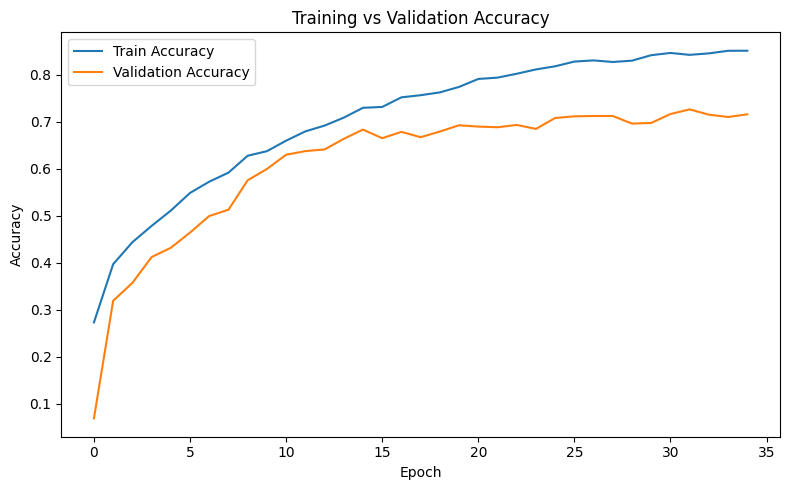

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# 5. Evaluating the CNN

- Evaluate the final model on the held-out test set.  
- Report test loss and accuracy as the main baseline metrics.  

In [13]:
test_loss, test_acc = model.evaluate(X_test_win, y_test_int, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

y_pred_probs = model.predict(X_test_win)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report:")
print(classification_report(
    y_test_int,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

Test loss: 0.8970
Test accuracy: 0.7132
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
Classification Report:
              precision    recall  f1-score   support

       blues       0.79      0.77      0.78       180
   classical       0.79      0.95      0.86       171
     country       0.77      0.24      0.36       180
       disco       0.70      0.67      0.68       180
      hiphop       0.65      0.83      0.73       180
        jazz       0.91      0.89      0.90       180
       metal       0.71      0.98      0.83       162
         pop       0.84      0.57      0.68       171
      reggae       0.63      0.76      0.69       180
        rock       0.48      0.52      0.50       180

    accuracy                           0.71      1764
   macro avg       0.73      0.72      0.70      1764
weighted avg       0.73      0.71      0.70      1764



In [14]:
report_dict = classification_report(
    y_test_int,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

genre_table = pd.DataFrame(report_dict).transpose()
genre_table = genre_table.iloc[:-3][["precision", "recall", "f1-score", "support"]]
genre_table = genre_table.round(3)

print(genre_table)

           precision  recall  f1-score  support
blues          0.793   0.767     0.780    180.0
classical      0.794   0.947     0.864    171.0
country        0.768   0.239     0.364    180.0
disco          0.695   0.672     0.684    180.0
hiphop         0.645   0.828     0.725    180.0
jazz           0.914   0.889     0.901    180.0
metal          0.715   0.975     0.825    162.0
pop            0.836   0.567     0.676    171.0
reggae         0.628   0.761     0.688    180.0
rock           0.477   0.517     0.496    180.0


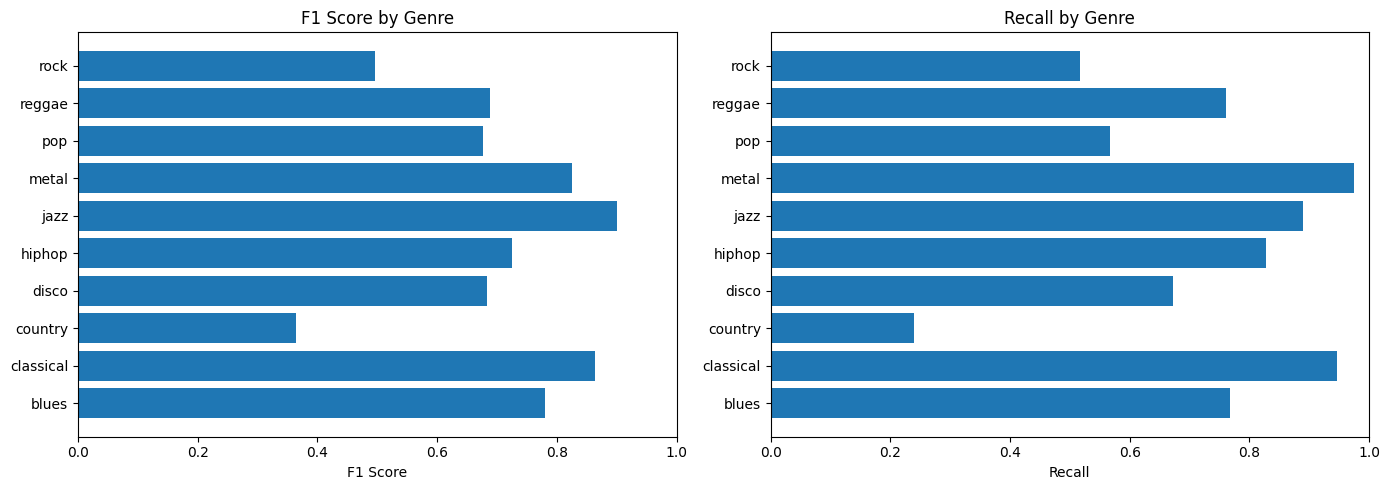

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(genre_table.index, genre_table["f1-score"])
axes[0].set_title("F1 Score by Genre")
axes[0].set_xlabel("F1 Score")
axes[0].set_xlim(0, 1)

axes[1].barh(genre_table.index, genre_table["recall"])
axes[1].set_title("Recall by Genre")
axes[1].set_xlabel("Recall")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

# 6. Summary and Next Steps

- Built and trained a 3-block CNN on log-mel spectrograms for 10-way genre classification.  
- Achieved a test accuracy of about 0.71 on the GTZAN test split using early stopping.  